In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import rasterio
from rasterio import plot
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import math
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.interpolate import griddata
import joblib
from tqdm import tqdm
import seaborn as sns
import geopandas as gpd
from shapely.geometry import box
from dataclasses import dataclass
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pyproj import Transformer

sns.set_theme()

In [2]:
from utils.site import Site
from utils.s2item import S2Item
from utils.tree import Tree
from utils.constants import (
    GHANA_GDF,
    GH_ASHANTI_GDF,
    ETHZ_COCOA_MAP_THRESHOLDED_FILEPATH,
    ETHZ_COCOA_MAP_FILEPATH,
    SILVER_FOLDERPATH,
    ETHZ_COCOA_MAP_UINT8_FILEPATH,
    SENTINEL_SCENES_FOLDERPATH,
)

In [3]:
# Load sites
sites = Site.load_all()
print(f"Loaded {len(sites)} sites")

Loaded 155 sites


In [4]:
# Load S2items of interest
s2items = S2Item.load_all()
print(f"Loaded {len(s2items)} S2Items")

Loaded 48 S2Items


Text(0.5, 1.0, 'Ghana with all (48) found S2items')

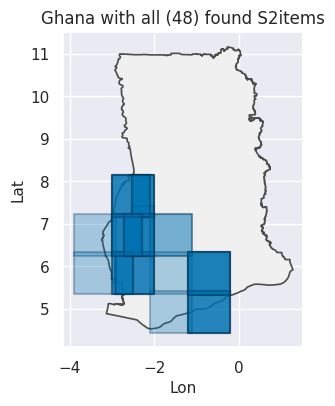

In [5]:
def plot_gdf(gdf: gpd.GeoDataFrame):
    # Plot base region
    gdf.plot(ax=plt.gca(), color="#f0f0f0", edgecolor="#4d4d4d", linewidth=1.2)
        
    plt.xlabel("Lon", fontsize=11)

    plt.ylabel("Lat", fontsize=11)

def plot_polygons(polygons: list[shapely.geometry.polygon.Polygon]) -> None:
    # Bounds -> gdf
    for p in polygons:
        bounds_gdf = gpd.GeoDataFrame({"geometry": [p]}, crs="epsg:4326")
        
        # Plot Sentinel patches as semi-transparent squares
        bounds_gdf.plot(ax=plt.gca(), color="#0072B2", edgecolor="#003554", alpha=0.3, linewidth=1.5)  
    
    plt.tight_layout()

# Convert the found patches into polygons
bboxes = list(set([e.bbox_wgs84 for e in s2items]))
polygons = [box(*e) for e in bboxes]

# Plot
fig = plt.figure(figsize=(4,4))
plot_gdf(GHANA_GDF)
plot_polygons(polygons)
plt.title(f"Ghana with all ({len(s2items)}) found S2items")

In [6]:
# Build a 10mx10m grid over Ghana
GRID_SPACING_M = 1_000

# Get the bounding box of the unioned geometry
bboxes = list(set([e.bbox_wgs84 for e in s2items]))
polygons = [box(*e) for e in bboxes]
s2item_gdf = gpd.GeoDataFrame(geometry=polygons, crs='EPSG:4326').to_crs(epsg=32630)
s2item_poly = s2item_gdf.union_all() # Project to a metric CRS (EPSG:32630 is in meters)
min_x, min_y, max_x, max_y = s2item_poly.bounds

# Generate 1D arrays of X and Y coordinates
x_coords = np.arange(min_x, max_x, GRID_SPACING_M)
y_coords = np.arange(min_y, max_y, GRID_SPACING_M)

# Create a 2D meshgrid from the 1D arrays
xx, yy = np.meshgrid(x_coords, y_coords)

# Flatten the grid coordinates into 1D arrays
xs = xx.flatten()
ys = yy.flatten()

# Convert to a GeoDataFrame
grid_points = gpd.GeoSeries.from_xy(xs, ys, crs=s2item_gdf.crs)
grid_gdf = gpd.GeoDataFrame(geometry=grid_points)

# Filter points to keep only those within the polygon boundaries
# This utilizes spatial indexing under the hood for better performance
grid_gdf = grid_gdf[grid_gdf.geometry.within(s2item_poly)].copy()

# Only keep the points within Ghana
ghana_metric = GHANA_GDF.to_crs(epsg=32630) # Project to a metric CRS (EPSG:32630 is in meters)
ghana_poly = ghana_metric.union_all()
grid_gdf = grid_gdf[grid_gdf.geometry.within(ghana_poly)].copy()

# Project back to WGS84 (Lat/Lon)
grid_gdf = grid_gdf.to_crs(epsg=4326)

# Extract final coordinates
grid_gdf["lon"] = grid_gdf.geometry.x
grid_gdf["lat"] = grid_gdf.geometry.y

print(f"Generated {len(grid_gdf)} valid grid points inside the region.")
grid_gdf.head(3)

Generated 75741 valid grid points inside the region.


,geometry,lon,lat
5133,POINT (-2.09173 4.54057),-2.091727,4.540574
5134,POINT (-2.08271 4.54056),-2.082713,4.540562
5135,POINT (-2.0737 4.54055),-2.073699,4.540551


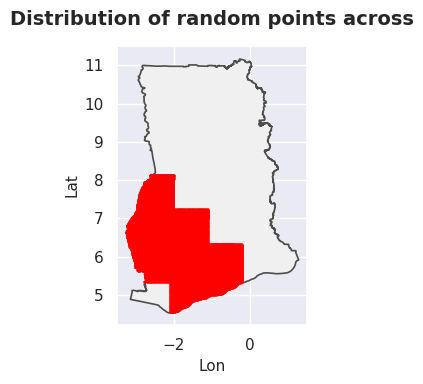

In [7]:
# Plot
def plot_map(gdf: gpd.GeoDataFrame, point_gdf: gpd.GeoDataFrame) -> None:
    fig, ax = plt.subplots(figsize=(6, 4))
    
    gdf.plot(ax=ax, color="#f0f0f0", edgecolor="#4d4d4d", linewidth=1.2)
    point_gdf.plot(ax=ax, color="RED", markersize=0.1, alpha=1.0)
    
    ax.set_title("Distribution of random points across", fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Lon", fontsize=11)
    ax.set_ylabel("Lat", fontsize=11)
    
    plt.tight_layout()
    plt.show()

plot_map(GHANA_GDF, grid_gdf)

In [8]:
# Subsample to be fast
gdf = grid_gdf.sample(100)

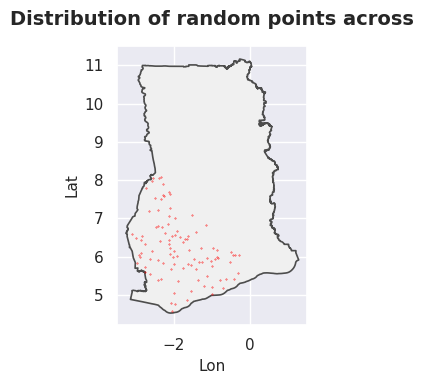

In [9]:
plot_map(GHANA_GDF, gdf)

In [10]:
# Select the most-relevant s2item for each point
s2_gdf = gpd.GeoDataFrame(
    {
        "s2item": s2items,
        "cloud_cover": [e.cloud_cover for e in s2items]
    },
    geometry=[e.gdf.geometry.iloc[0] for e in s2items], 
    crs=gdf.crs  # CRITICAL: Both GeoDataFrames must have the exact same CRS!
)

# 2. Perform a Spatial Join
# This matches each point in `gdf` to any intersecting polygons in `s2_gdf` using a fast spatial index.
# The index of 'joined' remains identical to the index of your original 'gdf'.
joined = gpd.sjoin(gdf, s2_gdf, how="left", predicate="intersects")

# 3. Find the least cloudy item per point
# Sort all matches by cloud cover ascending (lowest first)
joined_sorted = joined.sort_values(by="cloud_cover")

# Drop duplicates based on the index (the original points).
# Because it's sorted, keeping the "first" retains the one with the lowest cloud cover.
least_cloudy = joined_sorted[~joined_sorted.index.duplicated(keep="first")]

# 4. Map the winning item back to your original GeoDataFrame
# This aligns perfectly because we preserved the original index
gdf["s2item"] = least_cloudy["s2item"]
gdf.head(3)

,geometry,lon,lat,s2item
117351,POINT (-1.95199 7.00964),-1.951995,7.009639,S2Item(id='S2B_30NXN_20200127_0_L2A')
16233,POINT (-2.06436 4.78477),-2.064363,4.784768,S2Item(id='S2B_30NXL_20200107_0_L2A')
82526,POINT (-0.9596 6.23794),-0.959598,6.237936,S2Item(id='S2A_30NYM_20200112_0_L2A')


In [12]:
# Extract each point's feature
def get_features(point: Point, s2item: S2Item) -> np.ndarray:
    ...    

In [11]:
# Separate the points into
# - is-within 1km radius of a site
# - not the above

# Convert all site locations to gdf
points = [Point(lon, lat) for s in sites for lat, lon in s.lat_lons]
site_gdf = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326")

# 2. Project BOTH DataFrames to the metric CRS for accurate distance calculations
metric_crs = "EPSG:32630"
grid_gdf = grid_gdf.to_crs(metric_crs)
site_gdf = site_gdf.to_crs(metric_crs)

# 3. Buffer the target points by 1000 meters (1km)
# Using .union_all() merges overlapping buffers into a single unified polygon.
# This makes the spatial intersection much faster!
target_buffer_area = site_gdf.geometry.buffer(1000).union_all()

# 4. Create a boolean mask checking if each grid point intersects the buffer area
mask_within_1km = grid_gdf.geometry.intersects(target_buffer_area)

# 5. Separate the grid points based on the mask
grid_within_1km_metric = grid_gdf[mask_within_1km].copy()
grid_outside_1km_metric = grid_gdf[~mask_within_1km].copy()

# 6. Project the separated DataFrames back to WGS84 (Lat/Lon)
points_within_1km = grid_within_1km_metric.to_crs("EPSG:4326")
points_outside_1km = grid_outside_1km_metric.to_crs("EPSG:4326")

print(f"Points within 1km: {len(points_within_1km)}")
print(f"Points outside 1km: {len(points_outside_1km)}")

Points within 1km: 505
Points outside 1km: 75236


In [35]:
# For each point, extract their features off the S2Items of interest
# TODO
df = ... # | point | features

In [ ]:
# Train-val split

In [ ]:
# Train an LGBM on these points

In [ ]:
# Measure the performance